# Finding Binodal of LJ Fluid

In [8]:
import jax.numpy as jnp
from jax import random, jit, lax, ops
from jax_md import space, energy, simulate
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Simulation parameters 
num_steps_equilibrium = 50000 # Equilibration steps
dt = 1e-3  # Time step
sigma = 1.0 # Lennard-Jones diameter
epsilon = 1.0 # Lennard-Jones depth
r_c = 2.5 * sigma # Cutoff radius
dim = 3 # Number of dimensions
num_bins = 100 # Number of bins for histogram
Nx_liquid = 14 # Number of particles in x direction
num_particles_liquid = Nx_liquid**3 # Total number of liquid particles


# Initial Preparation of Liquid Slab Surrounded by Vapor

In [10]:
def prepare_simulation(rho_liquid, rho_vapor, kT, key):
    # --- Initial setup ---
    spacing_liquid = (1.0 / rho_liquid) ** (1.0 / dim)
    max_offset = (spacing_liquid - sigma) / 2

    Lx = Ly = Nx_liquid * spacing_liquid
    Lz = 3 * Lx
    box = jnp.array([Lx, Ly, Lz])

    z_thickness_liquid = Lz / 3
    z_center = Lz / 2
    z_min_liquid = z_center - z_thickness_liquid / 2
    z_max_liquid = z_center + z_thickness_liquid / 2

    # --- Liquid slab lattice ---
    grid_liquid = jnp.array([r for r in np.ndindex((Nx_liquid, Nx_liquid, Nx_liquid))])
    pos_liquid = grid_liquid * spacing_liquid
    pos_liquid = pos_liquid.at[:, 2].add(z_min_liquid)

    
    key, subkey = random.split(key)
    random_offset = random.uniform(subkey, shape=pos_liquid.shape, minval=-max_offset, maxval=max_offset)
    pos_liquid += random_offset

    # --- Vapor particles randomly placed outside slab ---
    vol_vapor = Lx * Ly * (Lz - z_thickness_liquid)
    num_vapor_particles = int(vol_vapor * rho_vapor)
    key, subkey = random.split(key)
    vapor_pos_all = random.uniform(subkey, shape=(num_vapor_particles * 2, 3)) * box
    z_vals = vapor_pos_all[:, 2]
    outside_mask = (z_vals < z_min_liquid) | (z_vals > z_max_liquid)
    pos_vapor = vapor_pos_all[outside_mask][:num_vapor_particles]

    # --- Combine all positions ---
    positions = jnp.concatenate([pos_liquid, pos_vapor], axis=0) % box
    num_particles = positions.shape[0]
    print(f"Number of Particles: {num_particles:.0f}")
    print(f"Initial Density: {num_particles/(Lx*Ly*Lz):.3f}")

    # --- Initialize dynamics ---
    displacement, shift = space.periodic(box)
    energy_fn = energy.lennard_jones_pair(displacement, sigma=sigma, epsilon=epsilon, r_cutoff=r_c, r_onset=0.8*r_c)
    energy_fn = jit(energy_fn)
    init_fn, apply_fn = simulate.nvt_langevin(energy_fn, shift, dt=dt, kT=kT)
    apply_fn = jit(apply_fn)
    init_state = init_fn(key, positions)

    return box, init_state, apply_fn


# Simulate to Equilibrate then Collect Density Histogram

In [11]:
def density_simulation(box, init_state, apply_fn, num_steps):
    dz = box[2] / num_bins
    volume_per_bin = box[0] * box[1] * dz

    # --- Equilibration phase ---
    @jit
    def equilibration_step(state, _):
        return apply_fn(state), None

    @jit
    def run_equilibration(state):
        return lax.scan(equilibration_step, state, xs=None, length=num_steps)[0]

    state = run_equilibration(init_state)

    # --- Sampling phase for density profile ---
    @jit
    def histogram_step(state_hist, _):
        state, hist = state_hist
        state = apply_fn(state)
        z = state.position[:, 2] % box[2]
        bin_idx = jnp.floor(z / dz).astype(int)
        bin_idx = jnp.clip(bin_idx, 0, num_bins - 1)
        bin_counts = ops.segment_sum(jnp.ones_like(bin_idx), bin_idx, num_bins)
        hist += bin_counts
        return (state, hist), None

    @jit
    def run_histogram_loop(state, init_hist):
        return lax.scan(histogram_step, (state, init_hist), xs=None, length=num_steps_equilibrium)

    init_hist = jnp.zeros(num_bins)
    (final_state, hist), _ = run_histogram_loop(state, init_hist)

    # --- Convert histogram to average density ---
    bin_edges = jnp.linspace(0.0, box[2], num_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    avg_density = hist / (num_steps_equilibrium * volume_per_bin)

    return bin_centers, avg_density



# Find Binodal by Simulating for Different Temperatures and Finding Liquid and Vapor Densities

Number of Particles: 2750
Initial Density: 0.267
Number of Particles: 2750
Initial Density: 0.267
Number of Particles: 2750
Initial Density: 0.267
Number of Particles: 2750
Initial Density: 0.267
Number of Particles: 2750
Initial Density: 0.267


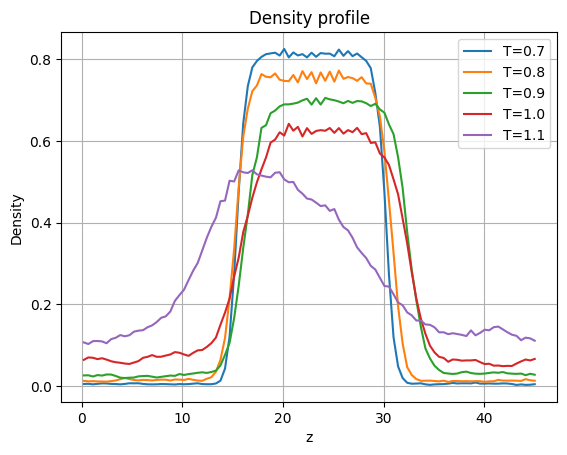

In [12]:
Temperatures=[0.7,0.8,0.9,1.0,1.1]
steps_list=[100000,200000,500000,1500000,2500000]
key = random.PRNGKey(0)
rho_l_init = 0.8
rho_v_init = 1e-3

binodal_liquid=[]
binodal_vapor=[]

for k in range(len(Temperatures)):
    box, init_state, apply_fn = prepare_simulation(rho_l_init, rho_v_init, Temperatures[k],key)
    bin_centers, density = density_simulation(box, init_state, apply_fn, steps_list[k])
    plt.plot(bin_centers, density, label=f'T={Temperatures[k]}')
    plt.xlabel('z')
    plt.ylabel('Density')
    density_max=jnp.max(density)
    density_min=jnp.min(density)
    rho_l=[]
    rho_v=[]
    for i in range(num_bins):
        if 0.9*density_max<=density[i]<=density_max:
            rho_l.append(density[i])
        if 1.1*density_min>=density[i]>=density_min:
            rho_v.append(density[i])
    binodal_liquid.append(jnp.mean(jnp.array(rho_l)))
    binodal_vapor.append(jnp.mean(jnp.array(rho_v)))
plt.legend()
plt.title('Density profile')
plt.grid()
plt.show()

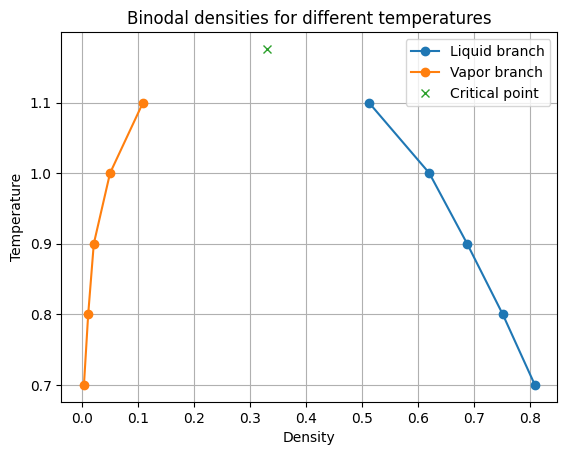

In [13]:
plt.plot(binodal_liquid, Temperatures, 'o-', label='Liquid branch')
plt.plot(binodal_vapor, Temperatures,  'o-', label='Vapor branch')
plt.plot(0.33,1.176,'x', label='Critical point')
plt.xlabel('Density')
plt.ylabel('Temperature')
plt.legend()
plt.title('Binodal densities for different temperatures')
plt.grid()
plt.show()

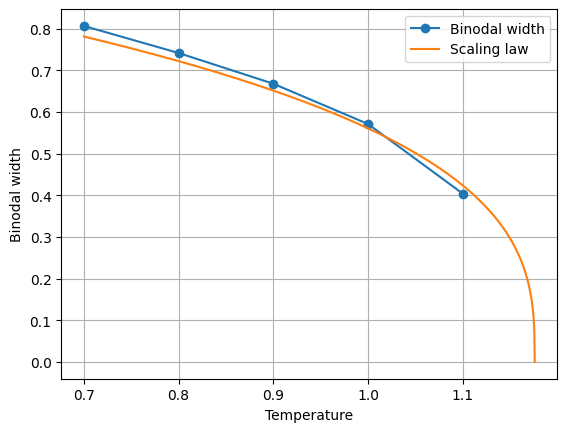

In [14]:
T_c=1.176
Ts=jnp.linspace(0.7,T_c,1000)
beta=1/3
plt.plot(Temperatures,jnp.array(binodal_liquid)-jnp.array(binodal_vapor), 'o-', label='Binodal width')
plt.plot(Ts,(T_c-Ts)**beta, '-', label='Scaling law')
plt.xlabel('Temperature')
plt.ylabel('Binodal width')
plt.legend()
plt.grid()
plt.show()